### 2.1

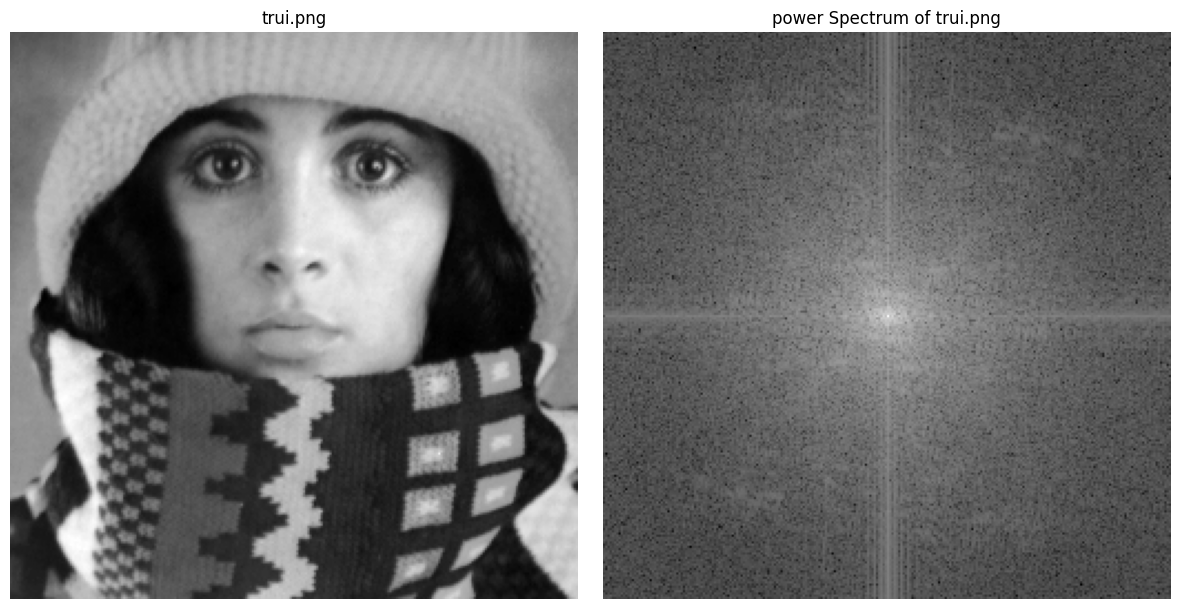

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from scipy.fft import fft2, fftshift

trui = io.imread('trui.png', as_gray = True)

trui_f = fft2(trui)
trui_shift = fftshift(trui_f)

trui_power = np.abs(trui_shift)**2

# plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(trui, cmap='gray')
axes[0].set_title('trui.png')
axes[0].axis('off')

axes[1].imshow(np.log(1 + trui_power), cmap='gray')
axes[1].set_title('power spectrum of trui.png')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 2.2

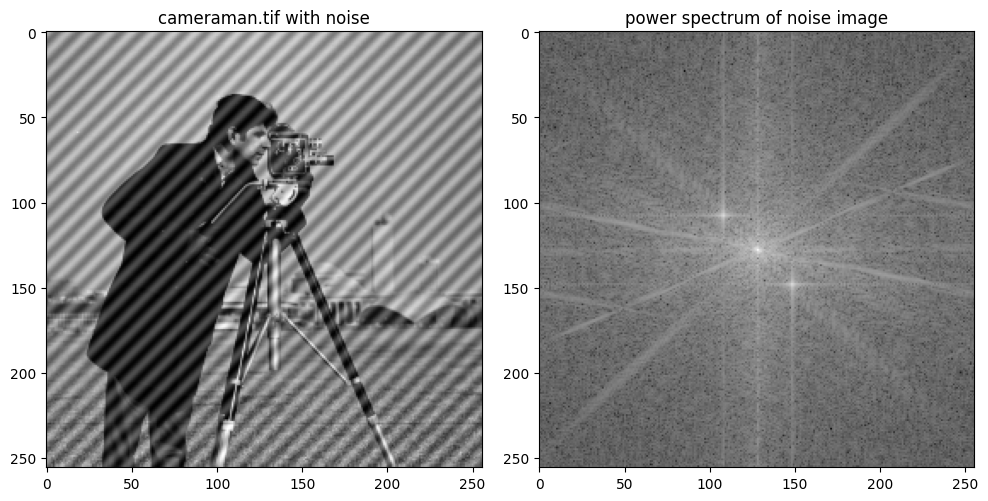

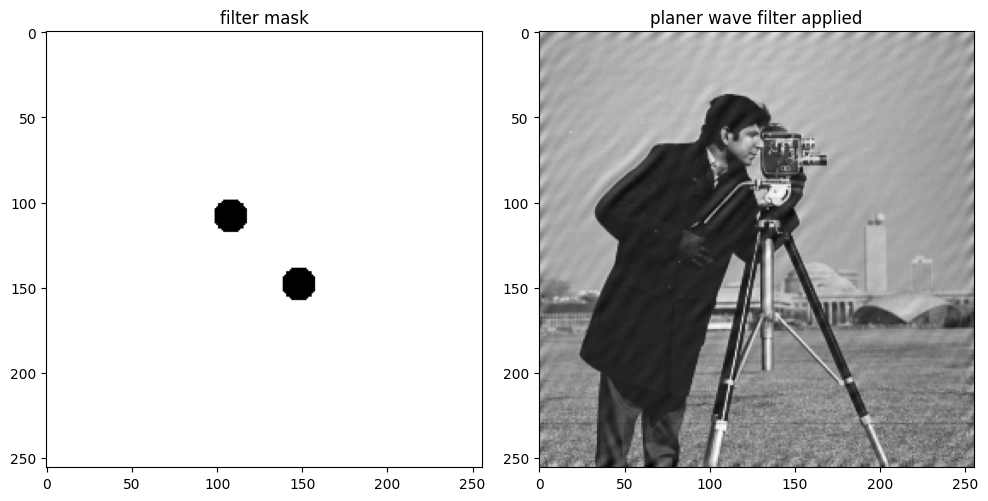

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, draw
from scipy.fft import fft2, fftshift, ifft2, ifftshift

img_cam = io.imread('cameraman.tif', as_gray=True)
M, N = img_cam.shape

# create wave
x = np.arange(N)
y = np.arange(M)
X, Y = np.meshgrid(x, y)
a0 = 50.0  
v0 = 0.5   
w0 = 0.5   

wave = a0 * np.cos(v0 * X + w0 * Y)
img_noisy = img_cam + wave

F_noisy = fftshift(fft2(img_noisy))
ps_noisy = np.abs(F_noisy)**2

# filter
H = np.ones((M, N))
# brightspots in power spectrum
rr1, cc1 = draw.disk((148, 148), 10, shape=(M, N))
rr2, cc2 = draw.disk((108, 108), 10, shape=(M, N))
H[rr1, cc1] = 0
H[rr2, cc2] = 0


F_filtered = F_noisy * H
img_restored = np.real(ifft2(ifftshift(F_filtered)))

# plotting
fig, axes = plt.subplots(1, 2, figsize=(10, 10))
axes[0].imshow(img_noisy, cmap='gray')
axes[0].set_title('cameraman.tif with noise')

axes[1].imshow(np.log(1 + ps_noisy), cmap='gray')
axes[1].set_title('power spectrum of noise image')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 10))
axes[0].imshow(H, cmap='gray')
axes[0].set_title('filter mask')

axes[1].imshow(img_restored, cmap='gray')
axes[1].set_title('planer wave filter applied')

plt.tight_layout()
plt.show()

### 2.3

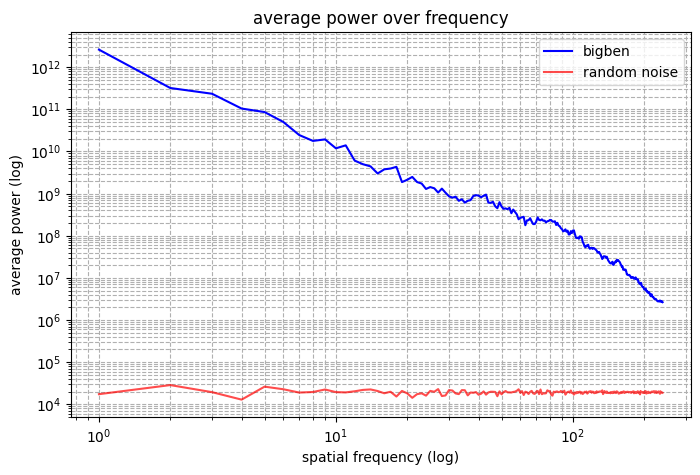

In [ ]:
def compute_radial_profile(power_spectrum):
    cy, cx = power_spectrum.shape[0] // 2, power_spectrum.shape[1] // 2
    y, x = np.indices((power_spectrum.shape))
    
    radii = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
    max_radius = min(cx, cy)
    
    radial_sum = np.bincount(radii.ravel(), power_spectrum.ravel())
    radial_count = np.bincount(radii.ravel())
    
    radial_avg = np.divide(radial_sum, radial_count, out=np.zeros_like(radial_sum), where=radial_count!=0)
    
    return np.arange(max_radius), radial_avg[:max_radius]


img_bb = io.imread('bigben_cropped_gray.png', as_gray=True)

# random noise image
img_noise = np.random.rand(*img_bb.shape)

ps_bb = np.abs(fftshift(fft2(img_bb)))**2
ps_noise = np.abs(fftshift(fft2(img_noise)))**2

freq_bb, radial_bb = compute_radial_profile(ps_bb)
freq_noise, radial_noise = compute_radial_profile(ps_noise)

# plotting
plt.figure(figsize=(8, 5))
plt.loglog(freq_bb[1:], radial_bb[1:], label='bigben', color='blue')
plt.loglog(freq_noise[1:], radial_noise[1:], label='random noise', color='red', alpha=0.7)
plt.title('average power over frequency')
plt.xlabel('spatial frequency (log)')
plt.ylabel('average power (log)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

### 2.4

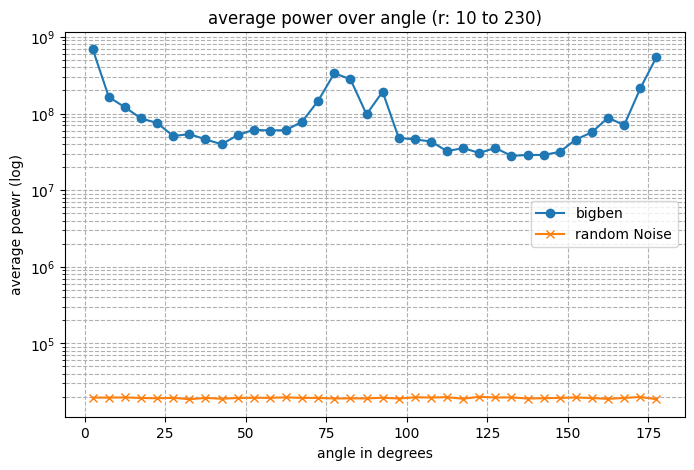

In [85]:
def compute_angular_profile(power_spectrum, min_r, max_r, num_bins=36):
    cy, cx = power_spectrum.shape[0] // 2, power_spectrum.shape[1] // 2
    y, x = np.indices((power_spectrum.shape))
    
    radii = np.sqrt((x - cx)**2 + (y - cy)**2)
    angles_deg = np.rad2deg(np.arctan2(y - cy, x - cx)) % 180
    
    mask = (radii >= min_r) & (radii <= max_r)
    
    bin_edges = np.linspace(0, 180, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    angular_avg = np.zeros(num_bins)
    
    for i in range(num_bins):
        angle_mask = (angles_deg >= bin_edges[i]) & (angles_deg < bin_edges[i+1])
        valid_pixels = power_spectrum[mask & angle_mask]
        if len(valid_pixels) > 0:
            angular_avg[i] = np.mean(valid_pixels)
            
    return bin_centers, angular_avg

min_r, max_r = 10, min(img_bb.shape)//2 - 10 
angles, angular_bb = compute_angular_profile(ps_bb, min_r, max_r)
angles, angular_noise = compute_angular_profile(ps_noise, min_r, max_r)

# plotting
plt.figure(figsize=(8, 5))

plt.semilogy(angles, angular_bb, label='bigben', marker='o')
plt.semilogy(angles, angular_noise, label='random Noise', marker='x')

plt.title(f'average power over angle (r: {min_r} to {max_r})')
plt.xlabel('angle in degrees')
plt.ylabel('average poewr (log)')
plt.legend()
plt.grid(True, which="both", ls="--") 
plt.show()

### 2.5

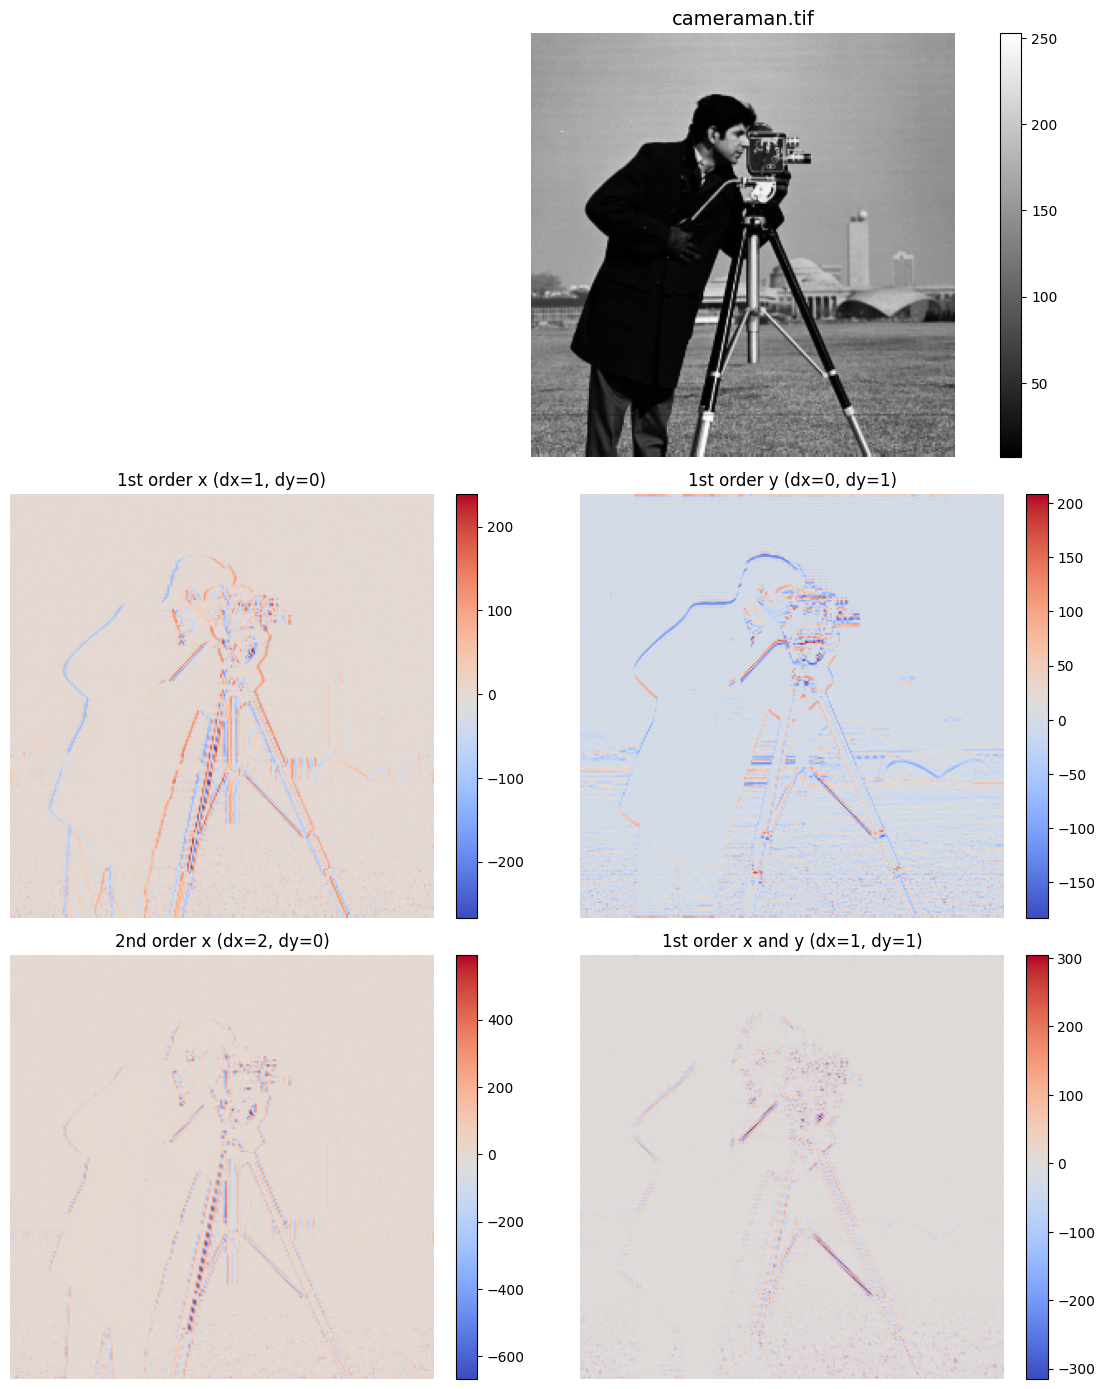

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from scipy.fft import fft2, ifft2

def compute_spectral_derivative(img, dx, dy):
    M, N = img.shape
    u = np.fft.fftfreq(N)
    v = np.fft.fftfreq(M)
    U, V = np.meshgrid(u, v)
    
    H = ((1j * 2 * np.pi * U)**dx) * ((1j * 2 * np.pi * V)**dy)
    
    F = fft2(img)
    F_deriv = F * H
    
    return np.real(ifft2(F_deriv))

img_cam = io.imread('cameraman.tif', as_gray=True)

# derivatives
d1x = compute_spectral_derivative(img_cam, dx=1, dy=0)
d1y = compute_spectral_derivative(img_cam, dx=0, dy=1)
d2x = compute_spectral_derivative(img_cam, dx=2, dy=0)
dxdy = compute_spectral_derivative(img_cam, dx=1, dy=1)

# plotting
fig = plt.figure(figsize=(12, 14)) 

ax_orig = plt.subplot2grid((3, 2), (0, 0), colspan=2)
im_orig = ax_orig.imshow(img_cam, cmap='gray')
ax_orig.set_title('cameraman.tif', fontsize=14)
ax_orig.axis('off')
fig.colorbar(im_orig, ax=ax_orig, fraction=0.046, pad=0.04)

ax_d1x = plt.subplot2grid((3, 2), (1, 0))
im_d1x = ax_d1x.imshow(d1x, cmap='coolwarm')
ax_d1x.set_title('1st order x (dx=1, dy=0)')
ax_d1x.axis('off')
fig.colorbar(im_d1x, ax=ax_d1x, fraction=0.046, pad=0.04)

ax_d1y = plt.subplot2grid((3, 2), (1, 1))
im_d1y = ax_d1y.imshow(d1y, cmap='coolwarm')
ax_d1y.set_title('1st order y (dx=0, dy=1)')
ax_d1y.axis('off')
fig.colorbar(im_d1y, ax=ax_d1y, fraction=0.046, pad=0.04)

ax_d2x = plt.subplot2grid((3, 2), (2, 0))
im_d2x = ax_d2x.imshow(d2x, cmap='coolwarm')
ax_d2x.set_title('2nd order x (dx=2, dy=0)')
ax_d2x.axis('off')
fig.colorbar(im_d2x, ax=ax_d2x, fraction=0.046, pad=0.04)

ax_dxdy = plt.subplot2grid((3, 2), (2, 1))
im_dxdy = ax_dxdy.imshow(dxdy, cmap='coolwarm')
ax_dxdy.set_title('1st order x and y (dx=1, dy=1)')
ax_dxdy.axis('off')
fig.colorbar(im_dxdy, ax=ax_dxdy, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()